# Final Dataset Exploratory Data Analysis (EDA)

### IMPORTANT: YOU MUST GENERATE FULL DATASET LOCALLY FIRST!
Due to strict data provider terms of service (specifically **Tiingo API** redistribution restrictions), **raw historical price and fundamental datasets CANNOT and WILL NOT be pre-uploaded or hosted directly on Kaggle**.

To use this EDA notebook, you must first build the dataset yourself:
1. Go to the official repository: **[S&P 500 Quantitative Dataset GitHub Repository](https://github.com/K0D1Z/sp500-quantitative-dataset)**
2. Follow the setup instructions, supply your free Tiingo API key, and run **`main.py`** locally or via Docker.
3. Once generated, upload your resulting `s_and_p_500_daily_features.parquet` file as a private/public dataset to Kaggle (or load it directly into your workspace).

*This notebook assumes you have already generated and attached your dataset (`s_and_p_500_daily_features.parquet`). Personally, I advise you to run the notebook locally once you generate dataset by running main.py - this notebook is available in the official repository*

## 1. Loading the Final Point-in-Time (PIT) Dataset

Once you have your generated dataset attached to the notebook, let's load it and inspect its structure. It contains over 1.6+ million rows and 45+ features, combining market prices, SEC EDGAR fundamentals (TTM normalized), valuation multiples, and technical indicators.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.options.display.max_columns = None
pd.options.display.max_rows = None

# Modify your paths if necessary
DATA_PATH = "../data/datasets/daily_features/s_and_p_500_daily_features.parquet"
EVENT_PATH = "../data/datasets/events/s_and_p_500_events.parquet"

try:
    df = pd.read_parquet(DATA_PATH)
    df['Date'] = pd.to_datetime(df['Date'])
    print(f"Main dataset loaded successfully! Shape: {df.shape[0]:,} rows, {df.shape[1]} columns.")
    events_df = pd.read_parquet(EVENT_PATH)
    print(f"Events dataset loaded successfully! Shape: {events_df.shape[0]:,} rows, {events_df.shape[1]} columns.")
    
except FileNotFoundError:
    print(f"Dataset not found at '{DATA_PATH} or {EVENT_PATH}'. Please ensure you followed the repository instructions to generate and upload the dataset first!")
    exit()

"""
Some companies may have had trading suspended, entered/exited the stock exchange, or exhibited unusual residual values on
specific historical dates. For analysis or machine learning, it's worth filtering out rows where Market Cap <= 0 or Close <= 0.
"""
df = df[(df['Market Cap'] > 0) & (df['Close'] > 0)]
duplicates_count = df.duplicated(subset=['Date', 'Ticker']).sum()
print(f"Duplicates count (Date + Ticker): {duplicates_count}")
df.head()

Main dataset loaded successfully! Shape: 1,550,344 rows, 51 columns.
Events dataset loaded successfully! Shape: 239 rows, 6 columns.
Duplicates count (Date + Ticker): 0


,Date,Ticker,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume,Split Multiplier,Split Shifted,Cum Split Factor,SMA_50,SMA_200,Volatility_30D,RSI_14,Filing Date,Period End,Form,Revenue,Cost of Revenue,R&D Expenses,SG&A Expenses,Operating Income,Net Income,EPS (Basic),EPS (Diluted),Total Assets,Current Assets,Cash and Equivalents,Total Liabilities,Current Liabilities,Long-Term Debt,Stockholders Equity,Operating Cash Flow,CapEx,Dividends Paid,Stock Repurchases,Shares Outstanding (Basic),Shares Outstanding (Diluted),CIK,Gross Profit,Operating Expenses,Market Cap,P/E Ratio,P/B Ratio,Company Name,GICS Sector,GICS Sub-Industry
0,2015-01-02,A,36.899380,NaN,40.560001,0.1,41.310001,40.369999,41.180000,0.0,1529200.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,2014-12-22,2012-10-31,10-K,6.858000e+09,NaN,1.158000e+09,3.168000e+09,1.960000e+09,NaN,5.40,5.33,1.053600e+10,4.629000e+09,2.351000e+09,5.351000e+09,1.893000e+09,2.112000e+09,5.182000e+09,2.624000e+09,4.550000e+08,1.740000e+08,3.620000e+08,3.480000e+08,3.530000e+08,1090872.0,NaN,NaN,1.431768e+10,7.609756,2.762964,Agilent Technologies,Health Care,Life Sciences Tools & Services
2,2015-01-02,AAL,51.079918,NaN,53.910000,0.0,54.599998,53.070000,54.279999,0.0,10748600.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,2014-02-28,2012-09-30,10-K,NaN,NaN,NaN,NaN,-8.960000e+08,-4.118000e+09,-32.90,-32.90,2.392700e+10,7.303000e+09,5.080000e+08,NaN,9.586000e+09,6.097000e+09,-7.375000e+09,5.099000e+09,3.734000e+09,NaN,NaN,1.252320e+08,1.252320e+08,6201.0,NaN,NaN,6.751257e+09,NaN,NaN,NaN,NaN,NaN
3,2015-01-02,AAP,137.392090,NaN,158.559998,0.0,162.500000,157.470001,160.850006,0.0,509800.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,2014-02-25,2012-10-06,10-K,1.104626e+10,5.542093e+09,NaN,4.295410e+09,1.208761e+09,7.172970e+08,9.62,9.45,4.357206e+09,2.947889e+09,4.793830e+08,NaN,2.380854e+09,5.995500e+08,1.147478e+09,1.980431e+09,6.980830e+08,5.812000e+07,6.865580e+08,7.316600e+07,7.399200e+07,1158449.0,5.504171e+09,NaN,1.173217e+10,16.778836,10.224310,NaN,NaN,NaN
4,2015-01-02,AAPL,24.192606,NaN,27.332500,0.0,27.860001,26.837500,27.847500,0.0,212818400.0,1.0,1.0,4.0,NaN,NaN,NaN,NaN,2014-10-27,2013-06-29,10-K,NaN,1.708510e+11,6.688000e+09,1.819700e+10,9.421000e+10,7.125800e+10,10.89,10.79,1.998560e+11,6.821900e+10,1.124800e+10,7.650200e+10,3.631900e+10,NaN,1.233540e+11,1.539700e+11,NaN,1.026500e+10,2.185000e+10,6.430323e+09,6.469854e+09,320193.0,1.190950e+11,3.823000e+09,7.073491e+11,10.132530,5.734302,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals"
5,2015-01-02,ABBV,41.119228,NaN,65.889999,0.0,66.400002,65.440002,65.440002,0.0,5086100.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,2014-02-21,2012-09-30,10-K,NaN,NaN,NaN,9.472000e+09,7.616000e+09,NaN,4.55,4.55,NaN,NaN,2.761000e+09,NaN,NaN,NaN,NaN,NaN,1.012000e+09,NaN,NaN,1.577000e+09,1.577000e+09,1551152.0,9.931000e+09,NaN,1.039085e+11,14.481319,NaN,AbbVie,Health Care,Biotechnology


### Event DataFrame Example Rows

In [2]:
events_df.head()

,Date,Removed Ticker,Removed Company Name,Added Ticker,Change Reason,Event Type
0,2015-01-27,COV,Covidien,ENDP,Covidien acquired by Medtronic[185],ACQUISITION
1,2015-01-27,SWY,Safeway,HCA,Safeway acquired by private equity consortium[...,ACQUISITION
2,2015-03-12,PETM,PetSmart,SWKS,PetSmart acquired by private equity consortium...,ACQUISITION
3,2015-03-18,CFN,Carefusion,HSIC,Carefusion acquired by Becton Dickinson[182],ACQUISITION
4,2015-03-23,NBR,Nabors Industries,SLG,Market Capitalization Changes.,MARKET_CAP


### Main DataFrame Non-Null Number of Rows

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 1473337 entries, 0 to 1550343
Data columns (total 51 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   Date                          1473337 non-null  datetime64[us]
 1   Ticker                        1473337 non-null  str           
 2   Adj Close                     1473337 non-null  float64       
 3   Capital Gains                 8011 non-null     float64       
 4   Close                         1473337 non-null  float64       
 5   Dividends                     1455272 non-null  float64       
 6   High                          1473337 non-null  float64       
 7   Low                           1473337 non-null  float64       
 8   Open                          1473337 non-null  float64       
 9   Stock Splits                  1473337 non-null  float64       
 10  Volume                        1473337 non-null  float64       
 11  Split Multipli

### Checking the Correctness of the Main DataFrame 

Check outliers and overall distribution.

In [4]:
print(df.describe())

                             Date     Adj Close  Capital Gains         Close  \
count                     1473337  1.473337e+06         8011.0  1.473337e+06   
mean   2020-08-26 12:56:49.908255  1.291994e+02            0.0  1.374393e+02   
min           2015-01-02 00:00:00  1.500000e-02            0.0  1.500000e-02   
25%           2017-12-05 00:00:00  3.448584e+01            0.0  3.989000e+01   
50%           2020-09-24 00:00:00  6.690789e+01            0.0  7.590000e+01   
75%           2023-05-30 00:00:00  1.289081e+02            0.0  1.409200e+02   
max           2025-12-31 00:00:00  1.760000e+04            0.0  1.760000e+04   
std                           NaN  4.262889e+02            0.0  4.264838e+02   

          Dividends          High           Low          Open  Stock Splits  \
count  1.455272e+06  1.473337e+06  1.473337e+06  1.473337e+06  1.473337e+06   
mean   6.759708e-03  1.391279e+02  1.356413e+02  1.373905e+02  2.983669e-04   
min    0.000000e+00  1.500000e-02  1.00000

### Check the rows where the report publication date is LATER than the market price date 
Validate for look-ahead bias

In [5]:
leakage = df[df['Date'] < df['Filing Date']]
print(f"Number of potential leaks look-ahead bias: {len(leakage)}")

Number of potential leaks look-ahead bias: 0


### Validate RSI and Volatility Range
RSI ranges from 0 to 100 and volatility cannot be negative.

In [6]:
invalid_rsi = df[(df['RSI_14'] < 0) | (df['RSI_14'] > 100)]['RSI_14'].count()
invalid_vol = df[df['Volatility_30D'] < 0]['Volatility_30D'].count()
print(f"Wrong RSI (outside the range 0-100): {invalid_rsi}")
print(f"Negative volatility: {invalid_vol}")

Wrong RSI (outside the range 0-100): 0
Negative volatility: 0


### Check for suspicious spikes (e.g., a change greater than 60% in one day)

A verification of extreme daily price movements (exceeding ±60%) identified 26 records across the entire dataset. A close inspection of these cases confirms that **these are neither data parsing errors nor API artifacts**, but rather a reflection of authentic, historical market events:

* **Meme Stocks Frenzy (January–February 2021):** The legendary surges of GameStop (`GME`) during the peak retail investor craze (e.g., gains exceeding 134% in a single day) are clearly visible.
* **Corporate Crises and Restructurings (`PCG`):** Severe fluctuations recorded for companies like Pacific Gas & Electric reflect market reactions to natural disasters, legal proceedings, and bankruptcy filings.
* **Biotech Volatility (`NKTR`):** Extreme price jumps and crashes in pharmaceutical companies stem directly from clinical trial readout publications.
* **AI Infrastructure & Tech Rallies (`LUMN`):** Sudden, powerful surges (such as short squeezes) driven by shifting market trends.

*Conclusion:* The dataset accurately and realistically captures market reality, correctly recording historical panics, euphorias, and liquidity anomalies without compromising the structure of the database.

In [7]:
# Quick calculation of daily change Adj Close
df['Daily_Return'] = df.groupby('Ticker')['Adj Close'].pct_change()
extreme_jumps = df[abs(df['Daily_Return']) > 0.60][['Date', 'Ticker', 'Adj Close', 'Daily_Return']]
print(f"Number of extreme daily spikes (>60%): {len(extreme_jumps)}")
if len(extreme_jumps) > 0:
    display(extreme_jumps.head(30))

Number of extreme daily spikes (>60%): 26


,Date,Ticker,Adj Close,Daily_Return
36335,2015-04-13,BLDR,11.570000,0.676812
158393,2016-03-04,COL,0.350000,0.750000
204188,2016-07-05,DHR,67.727310,0.612184
428405,2018-02-14,FOSL,16.969999,0.877212
559171,2019-01-24,PCG,13.710784,0.745933
841022,2021-01-26,GME,36.994999,0.927074
841188,2021-01-26,PBI,11.043635,0.810093
841569,2021-01-27,FOSL,23.660000,0.870356
841585,2021-01-27,GME,86.877502,1.348358
842711,2021-01-29,GME,81.250000,0.678719


## 2. Handling NaNs & Industry-Specific Accounting

As noted in the documentation, **not all columns are 100% populated**. Financial institutions (banks like JPMorgan or Bank of America) do not report *Cost of Revenue* or *Gross Profit* under US-GAAP, and many other columns might be missing depending on disclosures or historical data availability. 

Let's comprehensively inspect the missing value percentages across all major feature categories.

In [8]:
# Key core columns grouped by category
feature_groups = {
    "Market & Price": ['Open', 'Close', 'Volume', 'Market Cap'],
    "Fundamentals (TTM)": ['Revenue', 'Cost of Revenue', 'Gross Profit', 'Operating Income', 'Net Income', 'Total Assets', 'Stockholders Equity', 'Operating Cash Flow'],
    "Valuation Multiples": ['P/E Ratio', 'P/B Ratio'],
    "Technical Indicators": ['SMA_50', 'SMA_200', 'Volatility_30D', 'RSI_14']
}

missing_report = {}

print("Percentage of Missing Values by Category:")
print("-" * 50)

for category, cols in feature_groups.items():
    # Filter only columns that actually exist in the dataframe
    valid_cols = [c for c in cols if c in df.columns]
    if valid_cols:
        cat_missing = df[valid_cols].isna().mean() * 100
        print(f"\n[{category}]")
        for col, val in cat_missing.items():
            print(f"  • {col:<22}: {val:.2f}% missing")

Percentage of Missing Values by Category:
--------------------------------------------------

[Market & Price]
  • Open                  : 0.00% missing
  • Close                 : 0.00% missing
  • Volume                : 0.00% missing
  • Market Cap            : 0.00% missing

[Fundamentals (TTM)]
  • Revenue               : 10.26% missing
  • Cost of Revenue       : 41.52% missing
  • Gross Profit          : 48.19% missing
  • Operating Income      : 17.66% missing
  • Net Income            : 1.51% missing
  • Total Assets          : 0.96% missing
  • Stockholders Equity   : 1.95% missing
  • Operating Cash Flow   : 1.16% missing

[Valuation Multiples]
  • P/E Ratio             : 11.53% missing
  • P/B Ratio             : 8.53% missing

[Technical Indicators]
  • SMA_50                : 0.30% missing
  • SMA_200               : 0.96% missing
  • Volatility_30D        : 0.33% missing
  • RSI_14                : 0.45% missing


## 3. Sector Distribution & Market Capitalization

Let's look at the distribution of companies across different Global Industry Classification Standard (GICS) sectors and analyze total market capitalization weightings.

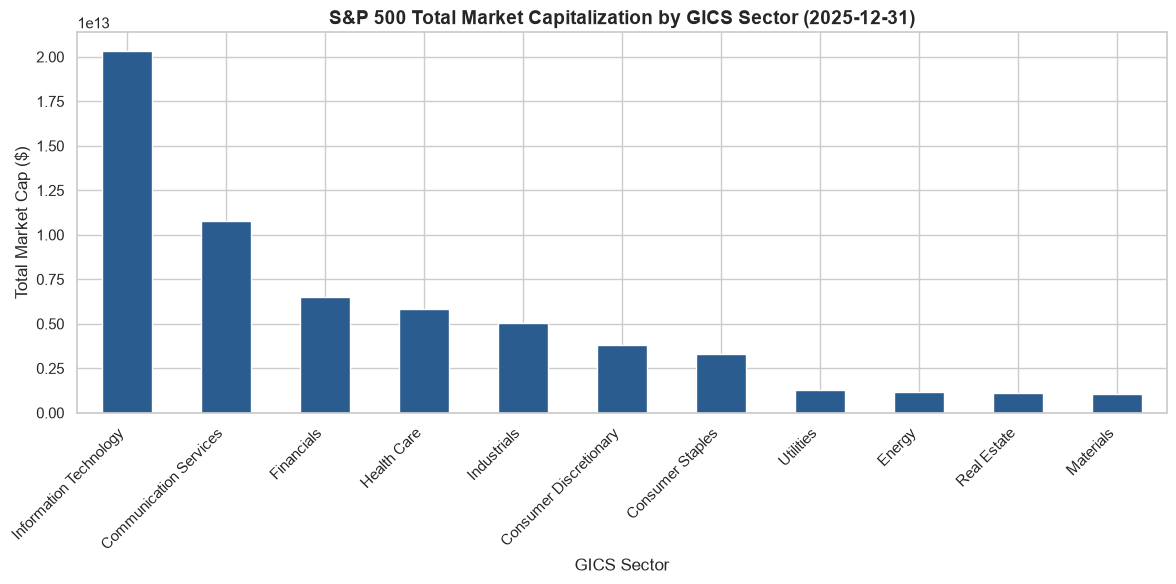

In [9]:
# Dynamically search for any sector-related column
sector_col = next((col for col in df.columns if 'sector' in col.lower()), None)

if sector_col and 'Market Cap' in df.columns:
    latest_date = df['Date'].max()
    latest_snapshot = df[df['Date'] == latest_date]
    
    sector_market_cap = latest_snapshot.groupby(sector_col)['Market Cap'].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    ax = sector_market_cap.plot(kind='bar', color='#2b5c8f')
    plt.title(f"S&P 500 Total Market Capitalization by {sector_col} ({latest_date.strftime('%Y-%m-%d')})", fontsize=14, fontweight='bold')
    plt.xlabel("GICS Sector", fontsize=12)
    plt.ylabel("Total Market Cap ($)", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"ℹNotice: Sector column not found in this dataset version.")
    print(f"Tip: Make sure you regenerated your dataset using the latest version of 'feature_engineering.py' via 'uv run main.py'.")

## 4. Point-in-Time Valuation Analysis (P/E Ratio)

Thanks to TTM (Trailing Twelve Months) normalization and backward cumulative split adjustment, P/E ratios reflect realistic historical valuations without look-ahead bias. Let's filter out extreme outliers and plot the distribution.

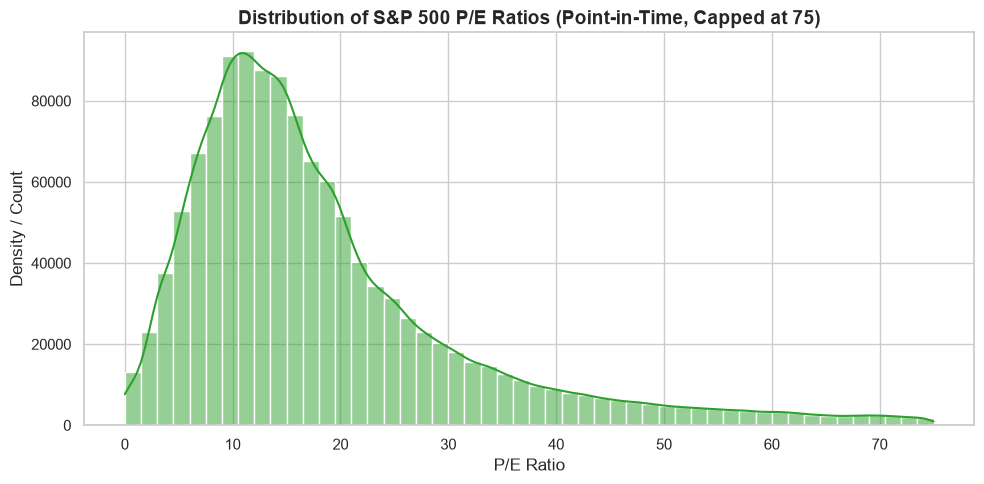

In [10]:
if 'P/E Ratio' in df.columns:
    # Filter for reasonable values to clean the visualization
    pe_clean = df[(df['P/E Ratio'] > 0) & (df['P/E Ratio'] <= 75)]['P/E Ratio']
    
    plt.figure(figsize=(10, 5))
    sns.histplot(pe_clean, bins=50, kde=True, color="#2ca02c")
    plt.title("Distribution of S&P 500 P/E Ratios (Point-in-Time, Capped at 75)", fontsize=14, fontweight='bold')
    plt.xlabel("P/E Ratio", fontsize=12)
    plt.ylabel("Density / Count", fontsize=12)
    plt.tight_layout()
    plt.show()

## 5. Technical Analysis Features (RSI & Volatility)

The feature engineering pipeline computes technical indicators like the 14-day Relative Strength Index (`RSI_14`) and 30-day rolling volatility (`Volatility_30D`) for every stock daily. Let's inspect the distribution of market volatility.

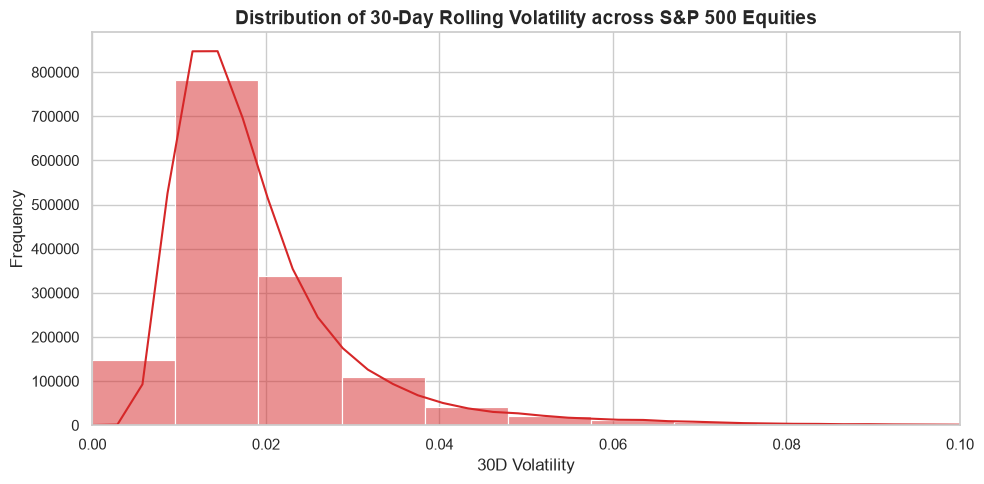

In [11]:
if 'Volatility_30D' in df.columns:
    vol_clean = df['Volatility_30D'].dropna()
    
    plt.figure(figsize=(10, 5))
    sns.histplot(vol_clean, bins=60, kde=True, color="#d62728")
    plt.title("Distribution of 30-Day Rolling Volatility across S&P 500 Equities", fontsize=14, fontweight='bold')
    plt.xlabel("30D Volatility", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xlim(0, 0.1) # Zooming into typical daily volatility ranges
    plt.tight_layout()
    plt.show()

## 6. Top 10 S&P 500 Companies by Market Capitalization

Let's inspect the largest corporate giants in the index based on their latest Point-in-Time Market Capitalization.

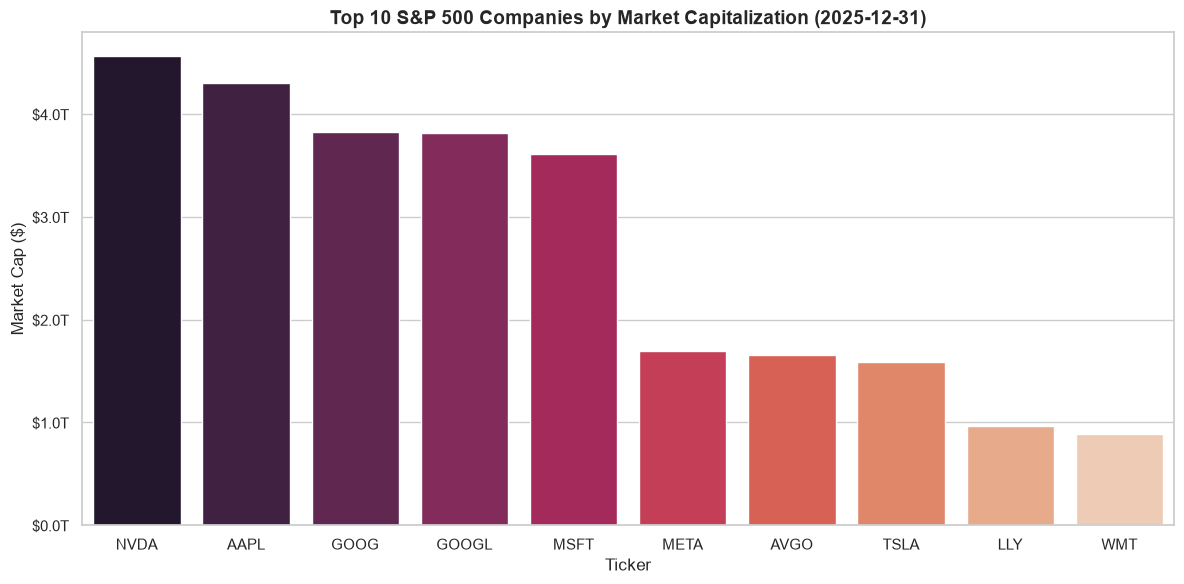

In [12]:
# Get the latest available date snapshot
latest_date = df['Date'].max()
latest_snapshot = df[df['Date'] == latest_date]

# Filter top 10 companies by market cap
top_10 = latest_snapshot.sort_values(by='Market Cap', ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_10, x='Ticker', y='Market Cap', palette='rocket', legend=False, hue="Ticker")
plt.title(f"Top 10 S&P 500 Companies by Market Capitalization ({latest_date.strftime('%Y-%m-%d')})", fontsize=14, fontweight='bold')
plt.xlabel("Ticker", fontsize=12)
plt.ylabel("Market Cap ($)", fontsize=12)

# Format y-axis to display in trillions for clarity
ax.yaxis.set_major_formatter(lambda x, pos: f'${x*1e-12:.1f}T')

plt.tight_layout()
plt.show()

## 7. Correlation Matrix of Financial & Technical Features

How do fundamental size metrics (like Revenue or Net Income) correlate with market valuations (P/E, P/B) and technical attributes (Volatility)? Let's generate a correlation heatmap.

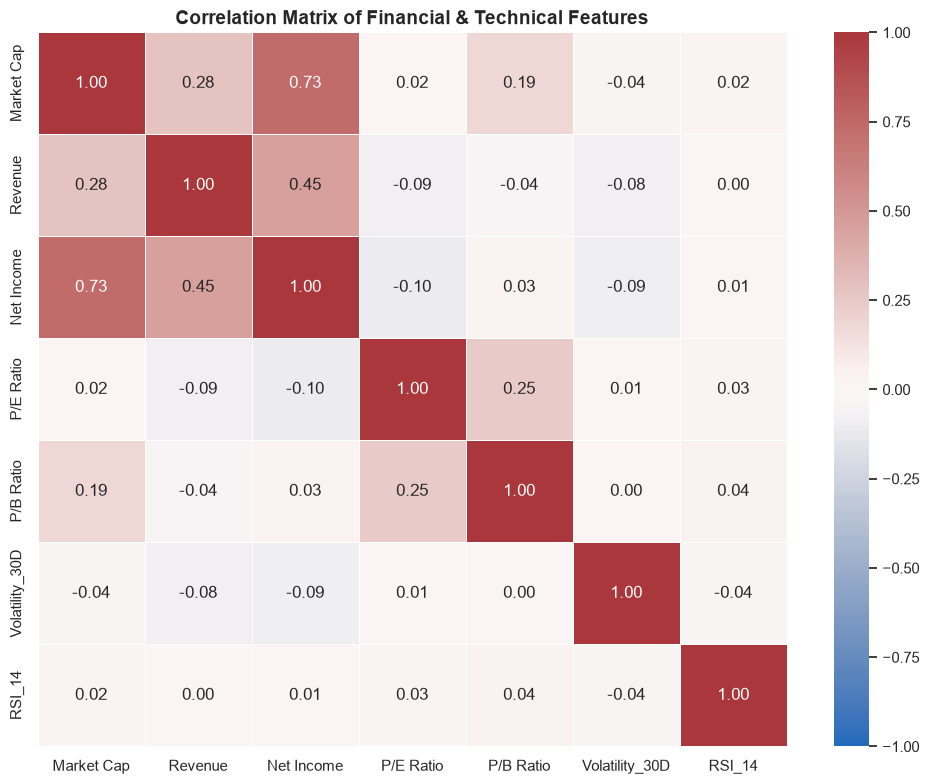

In [13]:
# Select key numerical features for correlation analysis
corr_cols = ['Market Cap', 'Revenue', 'Net Income', 'P/E Ratio', 'P/B Ratio', 'Volatility_30D', 'RSI_14']
valid_corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(10, 8))
corr_matrix = df[valid_corr_cols].corr()

# Plot heatmap
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='vlag', 
    fmt=".2f", 
    linewidths=0.5, 
    cbar=True,
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix of Financial & Technical Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. P/E ratio evolution for the whole S&P500

Let's explore how the valuations of the entire market have changed over the years (from 2015 to now), which allows to detect periods of "bubbles" or sell-offs.

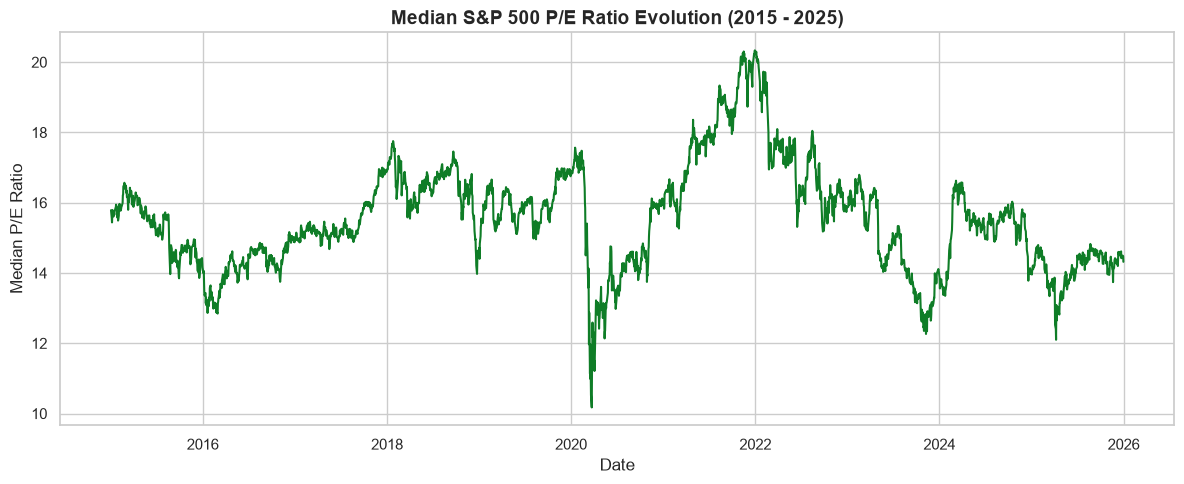

In [14]:
# Average P/E ratio over time (median for the entire index on a given day)
pe_over_time = df.groupby('Date')['P/E Ratio'].median().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(pe_over_time['Date'], pe_over_time['P/E Ratio'], color="#0f7d27", linewidth=1.5)
plt.title("Median S&P 500 P/E Ratio Evolution (2015 - 2025)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Median P/E Ratio", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Number of changes in the index composition (Corporate Turnover / Index Exits over time)

Let's explore turnover dynamics in the index (how many companies left the S&P 500 each year and for what reasons).

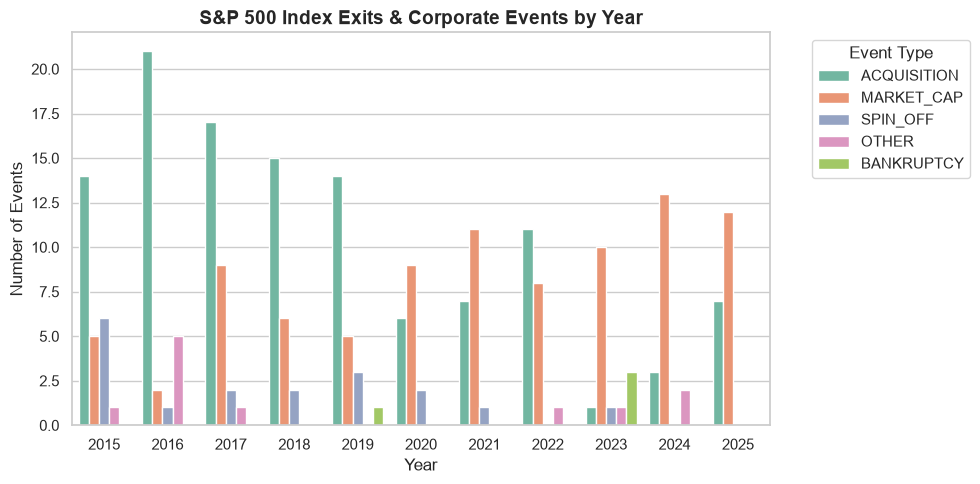

In [15]:
events_df['Year'] = pd.to_datetime(events_df['Date']).dt.year

plt.figure(figsize=(10, 5))
sns.countplot(data=events_df, x='Year', hue='Event Type', palette='Set2')
plt.title("S&P 500 Index Exits & Corporate Events by Year", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Events", fontsize=12)
plt.legend(title="Event Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. Cumulative rates of return of selected sectors (Sector Performance)

Let's explore which GICS sector generated the highest return (growth vs value / tech vs utilities) during the analyzed period.

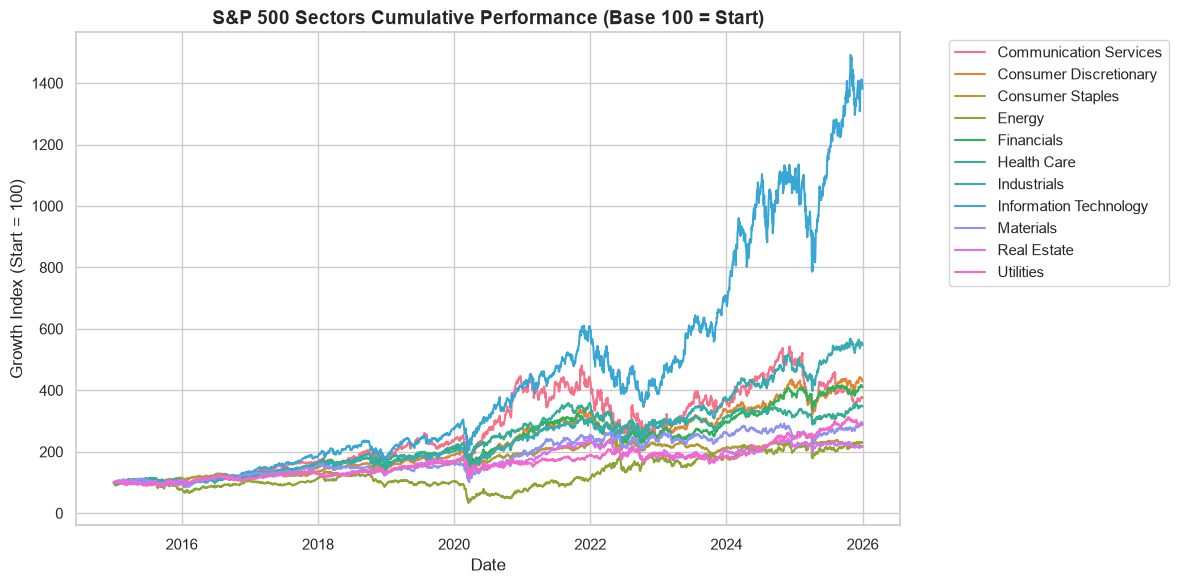

In [16]:
sector_col = next((col for col in df.columns if 'sector' in col.lower()), None)

if sector_col:
    # Find the initial price for each ticker
    df = df.sort_values(['Ticker', 'Date'])
    df['Initial Price'] = df.groupby('Ticker')['Adj Close'].transform('first')
    
    # Normalize each company so it has a value of 100 on its first day
    df['Normalized Price'] = (df['Adj Close'] / df['Initial Price']) * 100
    
    # Calculate the average normalized price for each sector over time
    sector_perf = df.groupby(['Date', sector_col])['Normalized Price'].mean().reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=sector_perf, x='Date', y='Normalized Price', hue=sector_col, linewidth=1.5)
    plt.title("S&P 500 Sectors Cumulative Performance (Base 100 = Start)", fontsize=14, fontweight='bold')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Growth Index (Start = 100)", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()